In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = {"Maths":[60,55,45,40,35],"Science":[54,34,75,85,69],"English":[69,58,29,42,68]}
df = pd.DataFrame(data)

In [4]:
df

,Maths,Science,English
0,60,54,69
1,55,34,58
2,45,75,29
3,40,85,42
4,35,69,68


In [7]:
df.mean()

Maths      47.0
Science    63.4
English    53.2
dtype: float64

In [8]:
df.mean(axis=1)

0    61.000000
1    49.000000
2    49.666667
3    55.666667
4    57.333333
dtype: float64

In [9]:
df.quantile()

Maths      45.0
Science    69.0
English    58.0
Name: 0.5, dtype: float64

In [10]:
df.sum()

Maths      235
Science    317
English    266
dtype: int64

In [15]:
df.mode()

,Maths,Science,English
0,35,34,29
1,40,54,42
2,45,69,58
3,55,75,68
4,60,85,69


In [16]:
df.corr()

,Maths,Science,English
Maths,1.000000,-0.725522,0.268365
Science,-0.725522,1.000000,-0.528235
English,0.268365,-0.528235,1.000000


<Axes: >

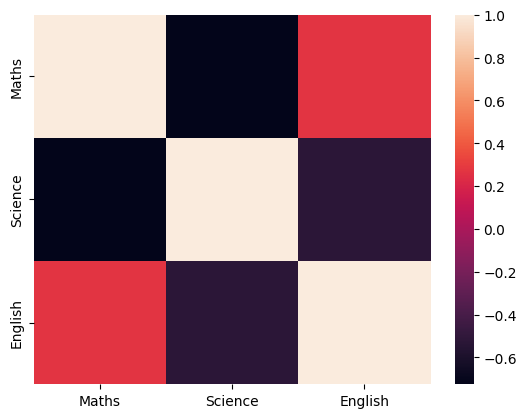

In [21]:
sns.heatmap(df.corr())

<Axes: >

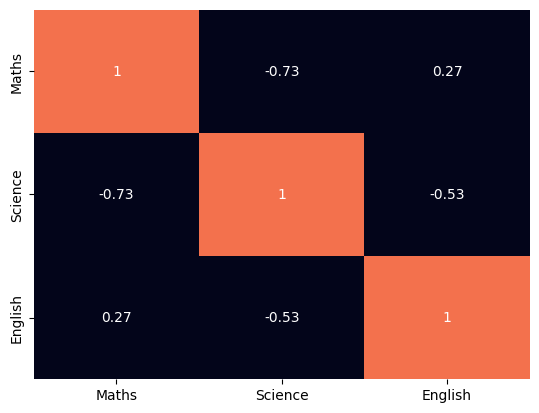

In [32]:
sns.heatmap(df.corr(),annot=True,cbar=False,vmin=0.3,vmax=1.3)

<Axes: >

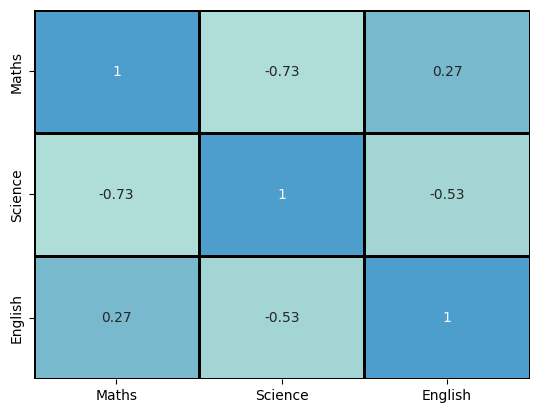

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap='icefire',cbar=False,vmin=-1,vmax=12,linewidths=2,linecolor='black')

<Axes: >

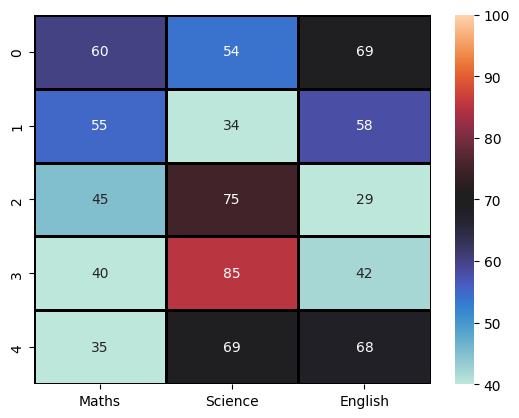

In [48]:
sns.heatmap(df,annot=True,cmap='icefire',cbar=True,vmin=40,vmax=100,linewidths=2,linecolor='black')

In [49]:
data1 = {'Values':[0,40,35,45,32,39,42,100]}
df = pd.DataFrame(data1)
df

,Values
0,0
1,40
2,35
3,45
4,32
5,39
6,42
7,100


In [50]:
q1 = df['Values'].quantile(0.25)
q3 = df['Values'].quantile(0.75)
iqr = q3 - q1
print(q1)
print(q3)
print(iqr)

34.25
42.75
8.5


In [51]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [52]:
outliner = df[(df["Values"]<lower_bound)|(df['Values']>upper_bound)] 
print(outliner)

   Values
0       0
7     100


In [54]:
cleen_df = df[(df['Values']>=lower_bound) & (df["Values"]<=upper_bound)]
print(cleen_df)

   Values
1      40
2      35
3      45
4      32
5      39
6      42


<Axes: ylabel='Values'>

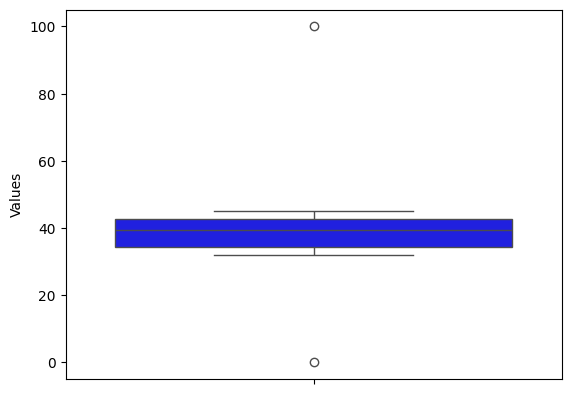

In [55]:
sns.boxplot(data = df['Values'],color='Blue')

<Axes: xlabel='Values'>

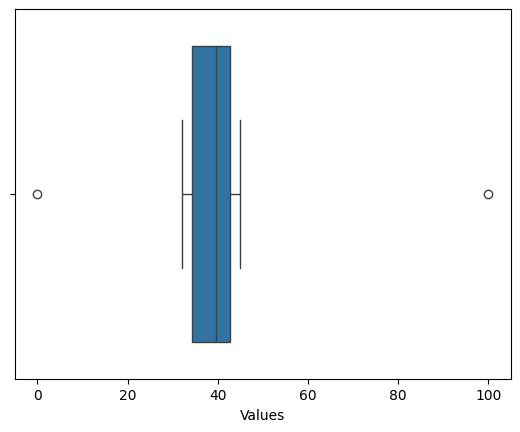

In [57]:
sns.boxplot(data = df,x=df['Values'])

In [59]:
data = {"Maths":[60,55,45,40,35],"Science":[54,34,75,85,69],"English":[69,58,29,42,68]}
df1 = pd.DataFrame(data)

In [60]:
df1['Categary'] = ['X','Y','X','Y','X']
df1

,Maths,Science,English,Categary
0,60,54,69,X
1,55,34,58,Y
2,45,75,29,X
3,40,85,42,Y
4,35,69,68,X


<Axes: xlabel='Maths', ylabel='Science'>

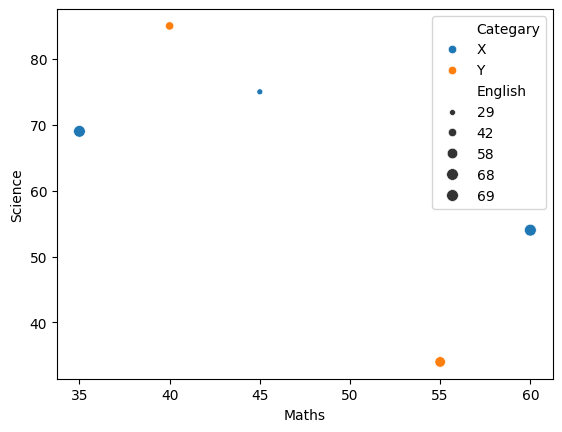

In [63]:
sns.scatterplot(data = df1,x = df1['Maths'],y=df1['Science'],hue='Categary',size='English')

array([[<Axes: xlabel='Maths', ylabel='Maths'>,
        <Axes: xlabel='Science', ylabel='Maths'>,
        <Axes: xlabel='English', ylabel='Maths'>],
       [<Axes: xlabel='Maths', ylabel='Science'>,
        <Axes: xlabel='Science', ylabel='Science'>,
        <Axes: xlabel='English', ylabel='Science'>],
       [<Axes: xlabel='Maths', ylabel='English'>,
        <Axes: xlabel='Science', ylabel='English'>,
        <Axes: xlabel='English', ylabel='English'>]], dtype=object)

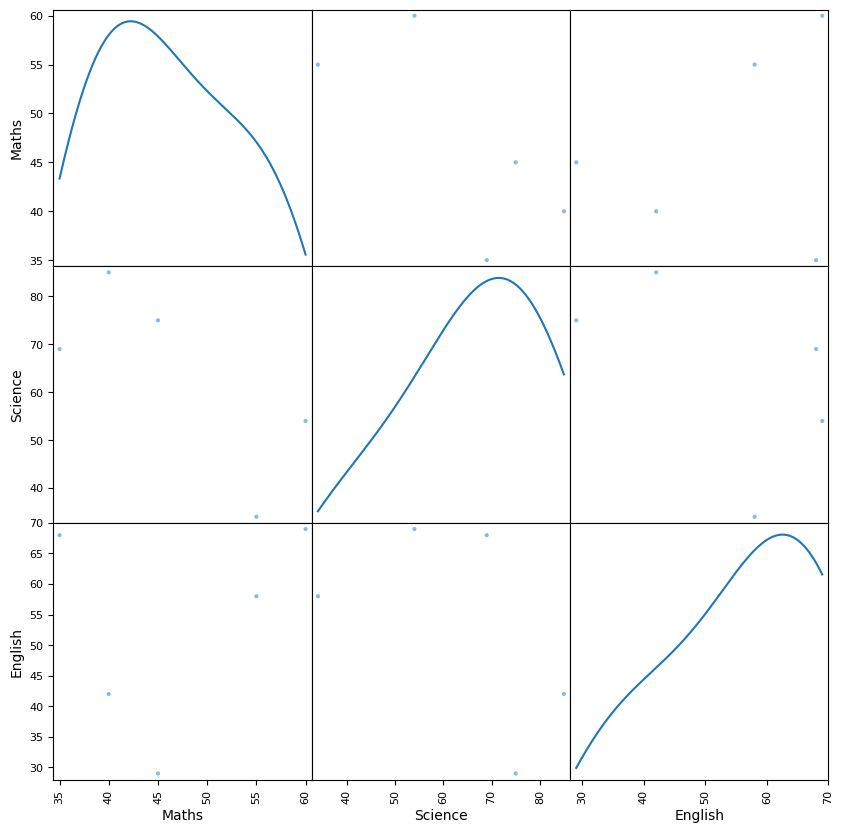

In [69]:
pd.plotting.scatter_matrix(df1,figsize=(10,10),diagonal='kde')

<Axes: >

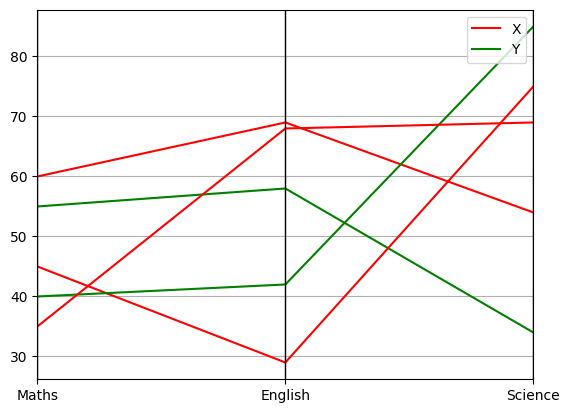

In [71]:
pd.plotting.parallel_coordinates(df1,"Categary",cols=['Maths','English','Science'],color=['red','green'])

In [72]:
df1['Gender'] = ['F','M','M','F','F']

In [74]:
df1

,Maths,Science,English,Categary,Gender
0,60,54,69,X,F
1,55,34,58,Y,M
2,45,75,29,X,M
3,40,85,42,Y,F
4,35,69,68,X,F


In [77]:
pd.crosstab(df1['Gender'],df1['Categary'],margins=True)

Categary,X,Y,All
Gender,,,
F,2,1,3
M,1,1,2
All,3,2,5


In [78]:
df1['Total'] = df['Maths'] + df['Science']
df1

,Maths,Science,English,Categary,Gender,Total
0,60,54,69,X,F,114
1,55,34,58,Y,M,89
2,45,75,29,X,M,120
3,40,85,42,Y,F,125
4,35,69,68,X,F,104


,Maths,Science,English
0,60,54,69
1,55,34,58
2,45,75,29
3,40,85,42
4,35,69,68


In [80]:
df['Total'] = df.apply(lambda x: x['Science']+x['Maths'],axis=1)
df

,Maths,Science,English,Total
0,60,54,69,114
1,55,34,58,89
2,45,75,29,120
3,40,85,42,125
4,35,69,68,104


In [81]:
df['Result'] = df.apply(lambda x: 'Pass' if x['Maths']>=40 and x['Science']>=40 and x['English']>=40 else 'Fail',axis=1)

In [82]:
df

,Maths,Science,English,Total,Result
0,60,54,69,114,Pass
1,55,34,58,89,Fail
2,45,75,29,120,Fail
3,40,85,42,125,Pass
4,35,69,68,104,Fail


In [86]:
df['age'] = [20,52,62,10,65]


In [87]:
df['Age'] = df.apply(lambda x: 'old' if x['age']>=40 else 'Adult' if x['age']>=18 else 'child',axis=1)
df

,Maths,Science,English,Total,Result,age,Age
0,60,54,69,114,Pass,20,Adult
1,55,34,58,89,Fail,52,old
2,45,75,29,120,Fail,62,old
3,40,85,42,125,Pass,10,child
4,35,69,68,104,Fail,65,old


In [88]:
data3 = {'DepartMent':['IT','IT','HR','FINANCE','HR','IT'],
         'Enployee':['A','B','C','D','E','F'],
         'Salary':[50000,60000,65000,45000,70000,55000],
         'Experince':[2,4,3,1,4,5]}

In [92]:
df3= pd.DataFrame(data3)
df3

,DepartMent,Enployee,Salary,Experince
0,IT,A,50000,2
1,IT,B,60000,4
2,HR,C,65000,3
3,FINANCE,D,45000,1
4,HR,E,70000,4
5,IT,F,55000,5


In [91]:
df3.groupby('DepartMent').mean(numeric_only=True)

,Salary,Experince
DepartMent,,
FINANCE,45000.0,1.000000
HR,67500.0,3.500000
IT,55000.0,3.666667


In [93]:
df3.groupby(['Salary','Experince']).sum()

,,DepartMent,Enployee
Salary,Experince,,
45000,1,FINANCE,D
50000,2,IT,A
55000,5,IT,F
60000,4,IT,B
65000,3,HR,C
70000,4,HR,E


In [97]:
df3.groupby('DepartMent',as_index=False).sum()

,DepartMent,Enployee,Salary,Experince
0,FINANCE,D,45000,1
1,HR,CE,135000,7
2,IT,ABF,165000,11


In [98]:
df3.groupby('DepartMent',sort=True).sum()

,Enployee,Salary,Experince
DepartMent,,,
FINANCE,D,45000,1
HR,CE,135000,7
IT,ABF,165000,11
